## **1. Setup**
---

In [ ]:
import os
import time
import random
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
def set_seed(seed, reproducibility=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility or Performance
    if reproducibility:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark     = True

## **2. Create Dataset**
---

In [ ]:
Triplet loss: 3 (anchor, positive, negative) images

Siamese network

In [ ]:
def gen_triplets(person_dirs, max_per_id=None): # Offline triplet mining
    triplets = []
    for d in person_dirs:
        imgs = [os.path.join(d, f) for f in os.listdir(d)]
        if len(imgs) < 2:
            continue

        anchor_pos = [(a, p) for i, a in enumerate(imgs) 
                             for p in imgs[i+1:]]
        if max_per_id:
            anchor_pos = random.sample(anchor_pos, min(max_per_id, len(anchor_pos)))

        for a, p in anchor_pos:
            neg_dir  = random.choice([x for x in person_dirs if x != d])
            n        = os.path.join(neg_dir, random.choice(os.listdir(neg_dir)))
            triplets.append((a, p, n))
    return triplets

# TODO: Try online triplet mining or hard negative mining

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, triplets, transform):
        self.triplets  = triplets
        self.transform = transform

    def __len__(self): return len(self.triplets)

    def _read(self, path): return Image.open(path).convert('RGB')

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return (self.transform(self._read(a)), self.transform(self._read(p)), self.transform(self._read(n)))

## **3. Create Model**
---

In [ ]:
class EmbeddingModel(nn.Module):
    def __init__(self, num_layers_to_unfreeze=10, backbone='efficientnet_b0'):
        super().__init__()

        self.base_model            = timm.create_model(backbone, pretrained=True) # Backbone
        self.base_model.classifier = nn.Identity()                                # Remove classifier head

        # Only unfreeze last `num_layers_to_unfreeze` layers
        for param in self.base_model.parameters():
            param.requires_grad = False
        for param in list(self.base_model.parameters())[-num_layers_to_unfreeze:]:
            param.requires_grad = True

        # MLP Head
        feat_dim = self.base_model.num_features
        self.embedding_head = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.SiLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
            nn.Linear(512, 256)     , nn.SiLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128)     , nn.SiLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 128)
        )

    def forward(self, x):
        feat = self.base_model(x)           # Extract feature from backbone, feat.shape=(B, feat_dim)
        emb  = self.embedding_head(feat)    # Get through MLP, emb.shape=(B, 128)
        emb  = F.normalize(emb, p=2, dim=1) # L2-normalize
        return emb

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss  = running_acc = 0.0
    total_samples = 0
    for a, p, n in tqdm(dataloader, desc='Training...', leave=False):
        a, p, n = a.to(device), p.to(device), n.to(device)

        optimizer.zero_grad()
        a_emb, p_emb, n_emb = model(a), model(p), model(n)
        loss                = criterion(a_emb, p_emb, n_emb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc  += (F.pairwise_distance(a_emb, p_emb, p=2) < 
                         F.pairwise_distance(a_emb, n_emb, p=2)).sum().item() # accuracy: ap_dist < an_dist
        total_samples += a.size(0)
    return running_loss / len(dataloader), running_acc / total_samples


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss  = running_acc = 0.0
    total_samples = 0
    with torch.no_grad():
        for a, p, n in tqdm(dataloader, desc='Validation...', leave=False):
            a, p, n = a.to(device), p.to(device), n.to(device)
    
            a_emb, p_emb, n_emb = model(a), model(p), model(n)
            loss                = criterion(a_emb, p_emb, n_emb)
            
            running_loss += loss.item()
            running_acc  += (F.pairwise_distance(a_emb, p_emb, p=2) < 
                             F.pairwise_distance(a_emb, n_emb, p=2)).sum().item() # accuracy: ap_dist < an_dist
            total_samples += a.size(0)
    return running_loss / len(dataloader), running_acc / total_samples


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs, save_path):    
    history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    
    start_time = time.time()
    for epoch in range(1, num_epochs+1):
        print(f"\n[Epoch {epoch}/{num_epochs}]")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(model, val_loader, criterion, device)
        
        # scheduler.step()
        scheduler.step(val_loss)
        
        print(f"-  Current LR: {scheduler.get_last_lr()[0]:.2e}")
        print(f"-  Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
        print(f"-  Val   Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'opt_state'  : optimizer.state_dict(),
                'sch_state'  : scheduler.state_dict(),
                'val_acc'    : val_acc
            }, save_path)
            print(f"-> Best model saved with val acc {best_val_acc:.4f}")
    end_time = time.time()
    
    print(f"\n=> Training complete in {(end_time - start_time):.2f}s. Best validation acc: {best_val_acc:.4f}")
    return history

## **4. Training**
---

In [ ]:
SEED = 42
set_seed(SEED, reproducibility=False)

DATA_DIR   = 'dataset/downloaded/Extracted Faces/Extracted Faces'
BATCH_SIZE = 32

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

MODEL_PATH = 'results/models/best_embedding_model.pth'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

In [ ]:
# Create triplets
person_dirs          = sorted([os.path.join(DATA_DIR, d) for d in os.listdir(DATA_DIR)])
train_dirs, val_dirs = train_test_split(person_dirs, test_size=0.2, random_state=SEED)

train_triplets       = gen_triplets(train_dirs, max_per_id=15)
val_triplets         = gen_triplets(val_dirs  , max_per_id=15)
print(f"Train triplets: {len(train_triplets)}")
print(f"Val   triplets: {len(val_triplets)}")

# Data Augmentation & DataLoader
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf   = transforms.Compose([
    transforms.Resize(150),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_loader = DataLoader(TripletDataset(train_triplets, train_tf), batch_size=BATCH_SIZE, 
                          shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(TripletDataset(val_triplets, val_tf), batch_size=BATCH_SIZE, 
                          shuffle=False, num_workers=4, pin_memory=True)
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

In [ ]:
# Train
emb_model = EmbeddingModel(num_layers_to_unfreeze=20, backbone='efficientnet_b1')
emb_model.to(DEVICE)

criterion = nn.TripletMarginLoss(margin=0.5, p=2)
optimizer = optim.AdamW(emb_model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

history = train_model(emb_model, train_loader, val_loader, 
                      criterion, optimizer, scheduler, DEVICE, 
                      num_epochs=30, save_path=MODEL_PATH)

cuda


model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]


[Epoch 1/30]


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...:   0%|          | 0/169 [00:00<?, ?it/s]

...

Validation...:   0%|          | 0/39 [00:00<?, ?it/s]

-  Current LR: 5.00e-05
-  Train Loss: 0.1597, Accuracy: 0.8781
-  Val   Loss: 0.2203, Accuracy: 0.8169

[Epoch 30/30]


Training...:   0%|          | 0/169 [00:00<?, ?it/s]

Validation...:   0%|          | 0/39 [00:00<?, ?it/s]

-  Current LR: 5.00e-05
-  Train Loss: 0.1567, Accuracy: 0.8825
-  Val   Loss: 0.2230, Accuracy: 0.8137

=> Training complete 992.08. Best validation acc: 0.8353


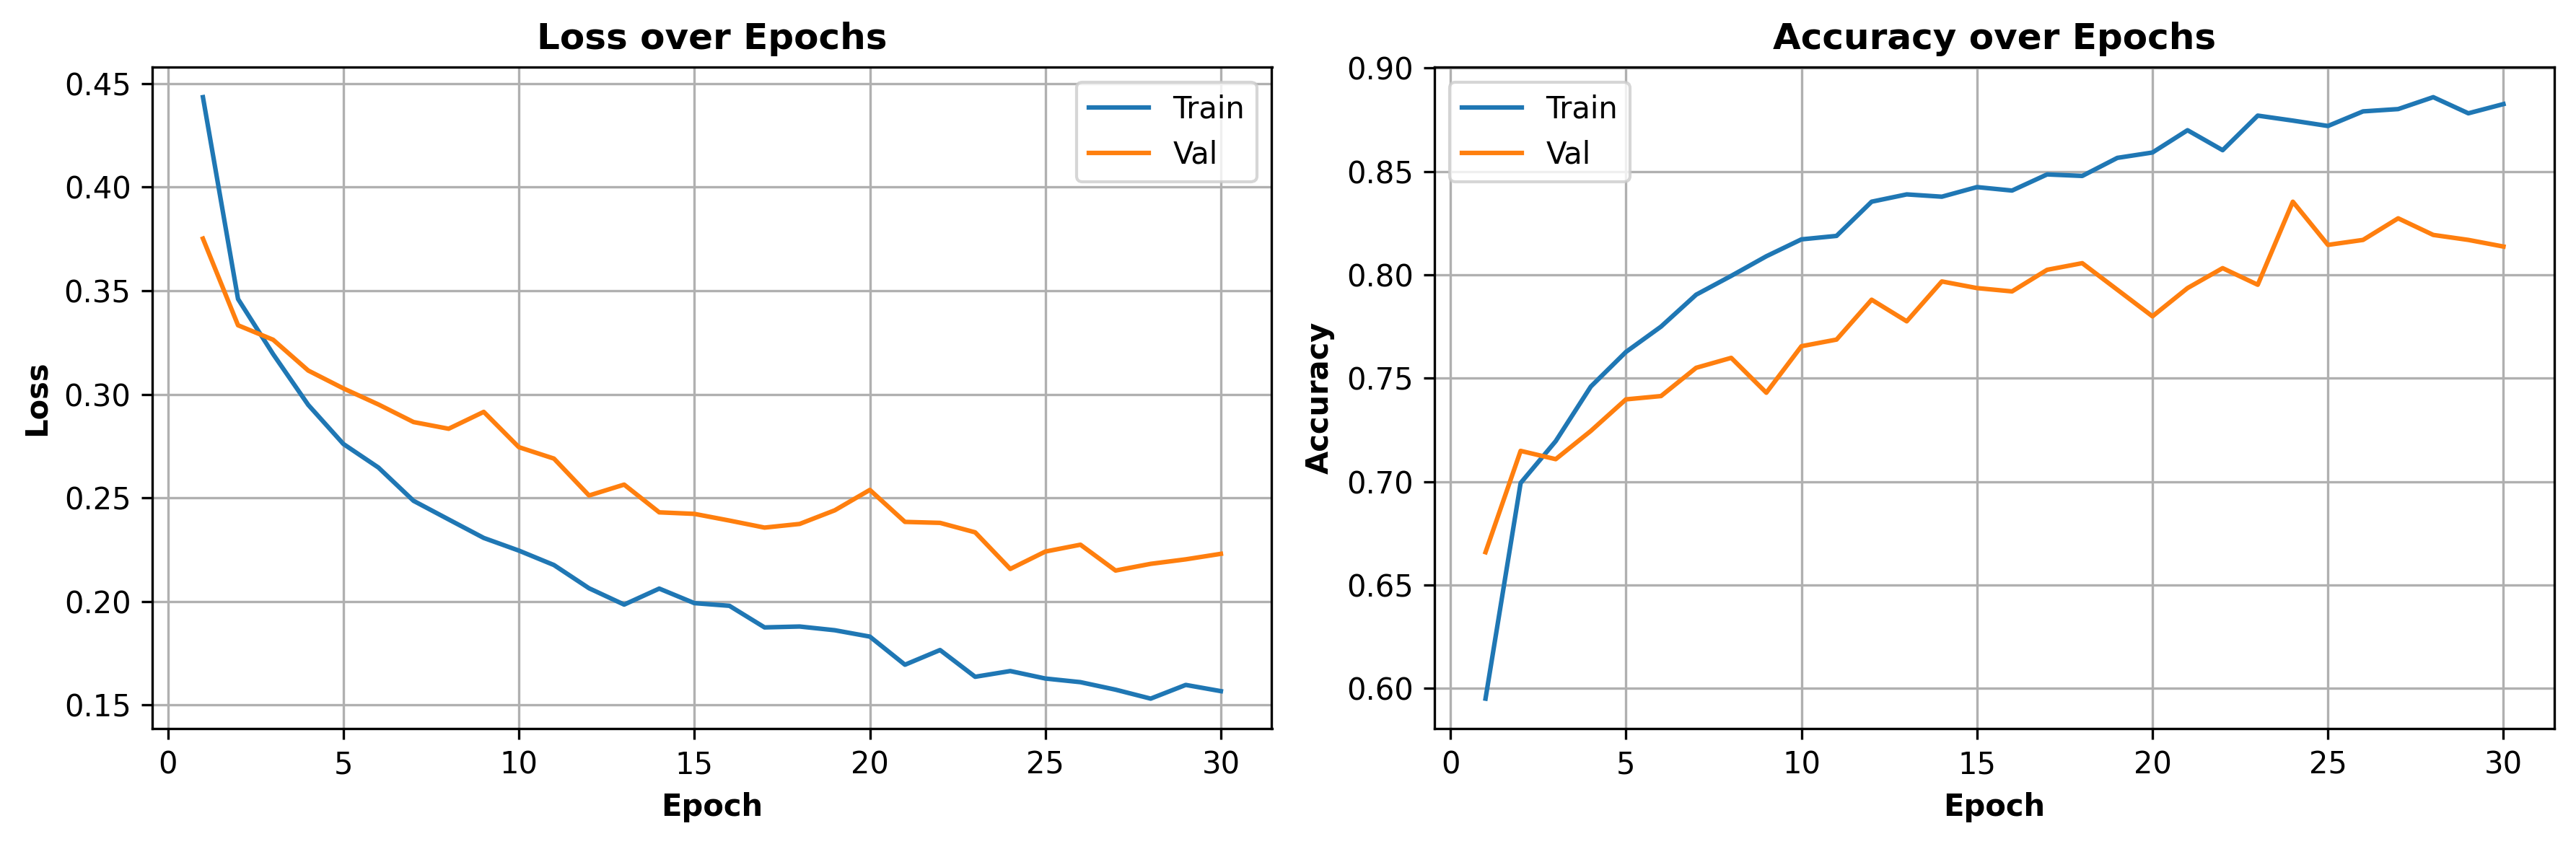

In [ ]:
# Plot training history
epochs_tick = range(1, len(history['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

for ax, metric, ylabel in zip(axs, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(epochs_tick, history[f'train_{metric}'], label='Train')
    ax.plot(epochs_tick, history[f'val_{metric}'],   label='Val')
    ax.set_title(f'{ylabel} over Epochs', fontweight='bold')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.legend()
    ax.grid(True)
    
plt.tight_layout()
plt.show()